# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

Zapisano obraz diagnostyczny: data/p01_sample_01.png


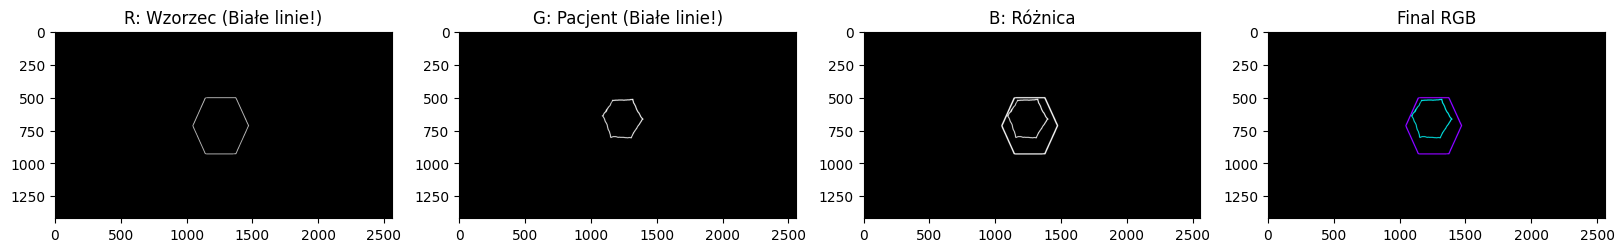

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(1417, 2560, 3), dtype=uint8)

In [6]:
import cv2
import numpy as np
import cairosvg
import io
from PIL import Image
import matplotlib.pyplot as plt

def render_svg_to_array(svg_path, width, height):
    try:
        # KLUCZ: Wymuszamy białe tło (background_color), aby uniknąć problemów z przezroczystością
        png_data = cairosvg.svg2png(
            url=svg_path,
            output_width=width,
            output_height=height,
            background_color="white" # To sprawi, że tło będzie miało 255, a linie 0
        )
        image = Image.open(io.BytesIO(png_data)).convert('L')
        return np.array(image)
    except Exception as e:
        print(f"Błąd renderowania SVG: {e}")
        return None

def create_debug_benton(svg_path, drawing_path, display_info, output_path=None):
    win_w, win_h = display_info['window_width'], display_info['window_height']
    img_w, img_h = display_info['image_width'], display_info['image_height']
    off_x, off_y = display_info['offset_x'], display_info['offset_y']

    # 1. PRZYGOTOWANIE WZORCA
    pattern_img = render_svg_to_array(svg_path, img_w, img_h)

    # DEBUG: Sprawdźmy wartości. Jeśli tło to 255, a linie to 0, to:
    # THRESH_BINARY_INV zamieni 255->0 (czarne tło) i 0->255 (białe linie)
    _, pattern_bin = cv2.threshold(pattern_img, 200, 255, cv2.THRESH_BINARY_INV)

    # Inicjalizacja płótna ZERAMI (czarne)
    full_pattern = np.zeros((win_h, win_w), dtype=np.uint8)

    # Sprawdzenie czy wymiary się zgadzają przed wklejeniem
    # pattern_bin ma wymiary (img_h, img_w)
    full_pattern[off_y:off_y+img_h, off_x:off_x+img_w] = pattern_bin

    # 2. RYSUNEK PACJENTA
    drawing_raw = cv2.imread(drawing_path, cv2.IMREAD_GRAYSCALE)
    drawing_res = cv2.resize(drawing_raw, (win_w, win_h))
    # Tutaj też robimy inwersję, bo rysunek to czarne linie (0) na białym (255)
    _, drawing_bin = cv2.threshold(drawing_res, 200, 255, cv2.THRESH_BINARY_INV)

    # 3. MAPA RÓŻNIC
    # Używamy dylatacji, żeby dać margines grubości kreski
    kernel = np.ones((7,7), np.uint8)
    pattern_dilated = cv2.dilate(full_pattern, kernel, iterations=1)
    diff_map = cv2.absdiff(pattern_dilated, drawing_bin)

    # 4. SKŁADANIE (Kolejność B, G, R dla OpenCV / R, G, B dla Matplotlib)
    # R=Wzorzec, G=Rysunek, B=Różnica
    diagnostic_rgb = cv2.merge([full_pattern, drawing_bin, diff_map])

    if output_path:
        # Konwersja RGB -> BGR przed zapisem przez OpenCV
        diagnostic_bgr = cv2.cvtColor(diagnostic_rgb, cv2.COLOR_RGB2BGR)
        cv2.imwrite(output_path, diagnostic_bgr)
        print(f"Zapisano obraz diagnostyczny: {output_path}")

    # --- WIZUALIZACJA ---
    plt.figure(figsize=(20, 5))
    plt.subplot(1,4,1); plt.imshow(full_pattern, cmap='gray'); plt.title("R: Wzorzec (Białe linie!)")
    plt.subplot(1,4,2); plt.imshow(drawing_bin, cmap='gray'); plt.title("G: Pacjent (Białe linie!)")
    plt.subplot(1,4,3); plt.imshow(diff_map, cmap='gray'); plt.title("B: Różnica")
    plt.subplot(1,4,4); plt.imshow(diagnostic_rgb); plt.title("Final RGB")
    plt.show()

    return diagnostic_rgb

# Przykład użycia
# create_and_show_benton(path_to_svg, path_to_drawing, my_display_info)

# Dane z Twojego JSONa
my_display_info = {
    "window_width": 2560,
    "window_height": 1417,
    "image_width": 1825,
    "image_height": 1417,
    "offset_x": 367,
    "offset_y": 0
}

# Ścieżki do plików
path_to_svg = "data/bvrt_c_2.svg"
path_to_drawing = "data/2_20260324_121419_159158_16_14.png"
output_file = "data/p01_sample_01.png"

create_debug_benton(path_to_svg, path_to_drawing, my_display_info, output_file)